In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Load dataset
file_path = "/content/drive/MyDrive/crop_health_jammu/data/WP1_FINAL_ALL_FEATURES_pointid.csv"
df = pd.read_csv(file_path)

# Sort properly to preserve time structure
df = df.sort_values(['point_id', 'Year', 'Month']).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Mounted at /content/drive
Dataset shape: (5541, 11)


,Year,Month,point_id,NDVI,NDMI,NDWI,EVI,LST,LST_anomaly,Rainfall,Rainfall_lag1
0,2018,6,0,0.687728,0.082619,-0.644273,0.436998,32.435957,2.694045,73.934509,NaN
1,2019,6,0,0.743909,0.152572,-0.671779,0.480969,32.134938,2.393026,62.198192,73.934509
2,2019,7,0,0.518622,0.161243,-0.404965,0.481283,24.086269,-1.333929,394.833817,62.198192
3,2019,8,0,0.731209,0.253154,-0.625645,0.599984,24.796311,0.696177,253.643950,394.833817
4,2019,9,0,0.772564,0.254707,-0.652993,0.471784,23.362406,-0.929274,205.866142,253.643950


In [ ]:
df[['NDVI','EVI','NDMI','NDWI','LST','Rainfall','Rainfall_lag1']].describe()

,NDVI,EVI,NDMI,NDWI,LST,Rainfall,Rainfall_lag1
count,5541.000000,5541.000000,5541.000000,5541.000000,5541.000000,5541.000000,5341.000000
mean,0.500486,0.384090,0.147926,-0.455228,25.953146,237.516308,238.425775
std,0.257669,0.921349,0.128829,0.222156,6.157630,175.289386,178.031351
min,-1.000000,-4.350000,-0.370213,-0.878797,6.410731,10.916122,10.916122
25%,0.330821,0.254395,0.064046,-0.627309,21.416766,95.504166,93.344403
50%,0.543709,0.377447,0.154734,-0.510125,26.581581,190.795826,189.332787
75%,0.720765,0.502306,0.239420,-0.327028,29.628017,326.237836,331.053999
max,0.907016,64.935924,0.902561,1.000000,47.356426,1063.825417,1063.825417


In [ ]:
print("NDVI = -1 count:", (df['NDVI'] == -1).sum())

NDVI = -1 count: 1


In [ ]:
df['EVI'].sort_values(ascending=False).head(10)

,EVI
5076,64.935924
3692,11.492671
3475,4.608930
5162,3.987498
2601,3.243243
1451,2.871046
1645,2.760974
1095,2.082331
4784,1.922853
4885,1.863971


In [ ]:
# Remove extreme EVI values
df = df[df['EVI'] <= 2]
df = df[df['EVI'] >= -2]

# Remove extreme NDVI noise
df = df[df['NDVI'] >= -0.5]

print("New shape after cleaning:", df.shape)

New shape after cleaning: (5520, 11)


In [ ]:
df[['NDVI','EVI','NDMI','NDWI']].describe()

,NDVI,EVI,NDMI,NDWI
count,5520.000000,5520.000000,5520.000000,5520.000000
mean,0.502114,0.373398,0.147914,-0.456873
std,0.255718,0.210993,0.128972,0.219691
min,-0.474979,-1.773456,-0.370213,-0.878797
25%,0.332255,0.255442,0.063857,-0.627870
50%,0.544488,0.377719,0.154688,-0.511299
75%,0.721380,0.502047,0.239472,-0.329269
max,0.907016,1.922853,0.902561,0.646356


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define full feature set
features = ['NDVI','EVI','NDMI','NDWI','LST','Rainfall','Rainfall_lag1']

# Remove rows with missing rainfall lag
df = df.dropna(subset=features)

scaler = StandardScaler()

# Standardize
X_scaled = scaler.fit_transform(df[features])

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)

principal_component = pca.fit_transform(X_scaled)

df['CHS_raw'] = principal_component

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.40813086]


In [ ]:
print(df[['CHS_raw','NDVI','LST']].corr())

          CHS_raw      NDVI       LST
CHS_raw  1.000000  0.942236 -0.127554
NDVI     0.942236  1.000000 -0.016944
LST     -0.127554 -0.016944  1.000000


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
chs_scaler = MinMaxScaler()

# Convert CHS_raw to 0-1 range
df['CHS'] = chs_scaler.fit_transform(df[['CHS_raw']])

# Check summary
print(df['CHS'].describe())

count    5320.000000
mean        0.617070
std         0.168565
min         0.000000
25%         0.495284
50%         0.637759
75%         0.752588
max         1.000000
Name: CHS, dtype: float64


In [ ]:
print("CHS standard deviation:", df['CHS'].std())

CHS standard deviation: 0.16856530851333634


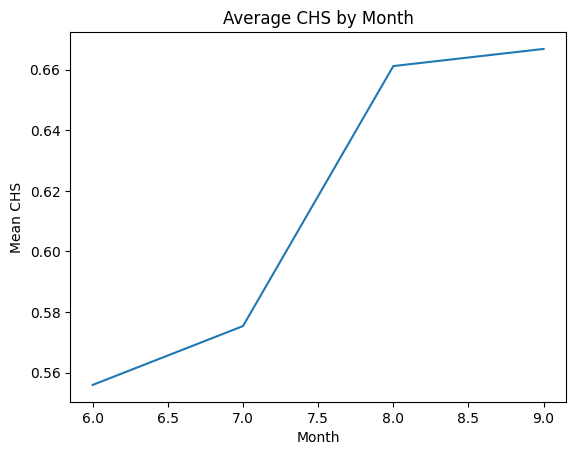

In [ ]:
import matplotlib.pyplot as plt

monthly_mean = df.groupby("Month")['CHS'].mean()

plt.plot(monthly_mean.index, monthly_mean.values)
plt.title("Average CHS by Month")
plt.xlabel("Month")
plt.ylabel("Mean CHS")
plt.show()

In [ ]:
# Final dataset for WP3
wp2_final = df.copy()

# Save to Drive
save_path = "/content/drive/MyDrive/crop_health_jammu/data/WP2_FINAL_PCA_CHS_2017_2025.csv"

wp2_final.to_csv(save_path, index=False)

print("WP2 saved successfully at:")
print(save_path)
print("Final shape:", wp2_final.shape)

WP2 saved successfully at:
/content/drive/MyDrive/crop_health_jammu/data/WP2_FINAL_PCA_CHS_2017_2025.csv
Final shape: (5320, 13)
